In [21]:
!pip install pyspark

In [22]:
from google.colab import files

uploaded = files.upload()

Saving employees.csv to employees (1).csv
Saving products.csv to products (1).csv
Saving sales.csv to sales (1).csv
Saving stores.csv to stores (1).csv


In [23]:
# IMPORT LIBRARIES

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

In [26]:
# CREATE SPARK SESSION

spark = SparkSession.builder \
    .appName("Retail Sales Analysis") \
    .getOrCreate()

print("Spark Session Created")

Spark Session Created


In [27]:
sales_df = spark.read.csv(
    "sales.csv",
    header=True,
    inferSchema=True
)

products_df = spark.read.csv(
    "products.csv",
    header=True,
    inferSchema=True
)

stores_df = spark.read.csv(
    "stores.csv",
    header=True,
    inferSchema=True
)

print("Sales Dataset")
sales_df.show(5)

print("Products Dataset")
products_df.show(5)

Sales Dataset
+-------+----------+--------+----------+-----------+--------+----------------+------------+
|sale_id| sale_date|store_id|product_id|employee_id|quantity|discount_percent|payment_mode|
+-------+----------+--------+----------+-----------+--------+----------------+------------+
|  SA101|2026-01-02|    S101|      P101|       E101|       2|              10| Credit Card|
|  SA102|2026-01-03|    S102|      P102|       E103|       3|               5|         UPI|
|  SA103|2026-01-04|    S103|      P103|       E105|       5|              15|        Cash|
|  SA104|2026-01-05|    S104|      P104|       E107|       4|               8|  Debit Card|
|  SA105|2026-01-06|    S105|      P105|       E109|       6|              12|         UPI|
+-------+----------+--------+----------+-----------+--------+----------------+------------+
only showing top 5 rows
Products Dataset
+----------+------------+-----------+-----+-----+--------+
|product_id|product_name|   category|price| cost|   brand|

In [28]:
#JOIN DATASETS

merged_df = sales_df.join(
    products_df,
    on="product_id",
    how="inner"
)

merged_df.show(5)

+----------+-------+----------+--------+-----------+--------+----------------+------------+------------+-----------+-----+-----+--------+
|product_id|sale_id| sale_date|store_id|employee_id|quantity|discount_percent|payment_mode|product_name|   category|price| cost|   brand|
+----------+-------+----------+--------+-----------+--------+----------------+------------+------------+-----------+-----+-----+--------+
|      P101|  SA101|2026-01-02|    S101|       E101|       2|              10| Credit Card|      Laptop|Electronics|55000|48000|    Dell|
|      P102|  SA102|2026-01-03|    S102|       E103|       3|               5|         UPI|  Smartphone|Electronics|30000|25000| Samsung|
|      P103|  SA103|2026-01-04|    S103|       E105|       5|              15|        Cash|  Headphones|Accessories| 2000| 1200|    Boat|
|      P104|  SA104|2026-01-05|    S104|       E107|       4|               8|  Debit Card|    Keyboard|Accessories| 1500|  900|Logitech|
|      P105|  SA105|2026-01-06|   

In [29]:
# CALCULATE REVENUE

from pyspark.sql.functions import col

merged_df = merged_df.withColumn(
    "revenue",
    col("quantity") * col("price")
)

merged_df = merged_df.withColumn(
    "discount_amount",
    col("revenue") * col("discount_percent") / 100
)

merged_df = merged_df.withColumn(
    "final_revenue",
    col("revenue") - col("discount_amount")
)

merged_df.show(5)

+----------+-------+----------+--------+-----------+--------+----------------+------------+------------+-----------+-----+-----+--------+-------+---------------+-------------+
|product_id|sale_id| sale_date|store_id|employee_id|quantity|discount_percent|payment_mode|product_name|   category|price| cost|   brand|revenue|discount_amount|final_revenue|
+----------+-------+----------+--------+-----------+--------+----------------+------------+------------+-----------+-----+-----+--------+-------+---------------+-------------+
|      P101|  SA101|2026-01-02|    S101|       E101|       2|              10| Credit Card|      Laptop|Electronics|55000|48000|    Dell| 110000|        11000.0|      99000.0|
|      P102|  SA102|2026-01-03|    S102|       E103|       3|               5|         UPI|  Smartphone|Electronics|30000|25000| Samsung|  90000|         4500.0|      85500.0|
|      P103|  SA103|2026-01-04|    S103|       E105|       5|              15|        Cash|  Headphones|Accessories| 200

In [30]:
# UNDERPERFORMING PRODUCTS

underperforming_products = merged_df.filter(
    col("quantity") < 3
)

print("Underperforming Products")

underperforming_products.select(
    "product_id",
    "product_name",
    "quantity",
    "final_revenue"
).show()

Underperforming Products
+----------+------------------+--------+-------------+
|product_id|      product_name|quantity|final_revenue|
+----------+------------------+--------+-------------+
|      P101|            Laptop|       2|      99000.0|
|      P106|        Television|       1|      41850.0|
|      P107|      Refrigerator|       2|      68400.0|
|      P108|   Washing Machine|       1|      27550.0|
|      P109|   Air Conditioner|       1|      39480.0|
|      P113|           Printer|       2|      22320.0|
|      P114|            Camera|       1|      62400.0|
|      P116|    Microwave Oven|       2|      17100.0|
|      P119|External Hard Disk|       2|      11280.0|
+----------+------------------+--------+-------------+



In [31]:
# STORE LEVEL SUMMARY

from pyspark.sql.functions import avg, sum

store_summary = merged_df.groupBy(
    "store_id"
).agg(
    sum("final_revenue").alias("total_revenue"),
    avg("final_revenue").alias("average_monthly_revenue")
)

print("Store Summary")

store_summary.show()

Store Summary
+--------+-------------+-----------------------+
|store_id|total_revenue|average_monthly_revenue|
+--------+-------------+-----------------------+
|    S105|      16374.0|                 8187.0|
|    S102|     100900.0|                50450.0|
|    S106|      58950.0|                29475.0|
|    S104|      67920.0|                33960.0|
|    S107|      77600.0|                38800.0|
|    S110|      53620.0|                26810.0|
|    S101|     117000.0|                58500.0|
|    S108|      36730.0|                18365.0|
|    S109|      50760.0|                25380.0|
|    S103|      30820.0|                15410.0|
+--------+-------------+-----------------------+



In [32]:
# SAVE OUTPUT FILES

underperforming_products.toPandas().to_csv(
    "underperforming_products.csv",
    index=False
)

store_summary.toPandas().to_csv(
    "store_summary.csv",
    index=False
)

print("CSV Files Saved Successfully")

CSV Files Saved Successfully


In [33]:
from google.colab import files

files.download("underperforming_products.csv")
files.download("store_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

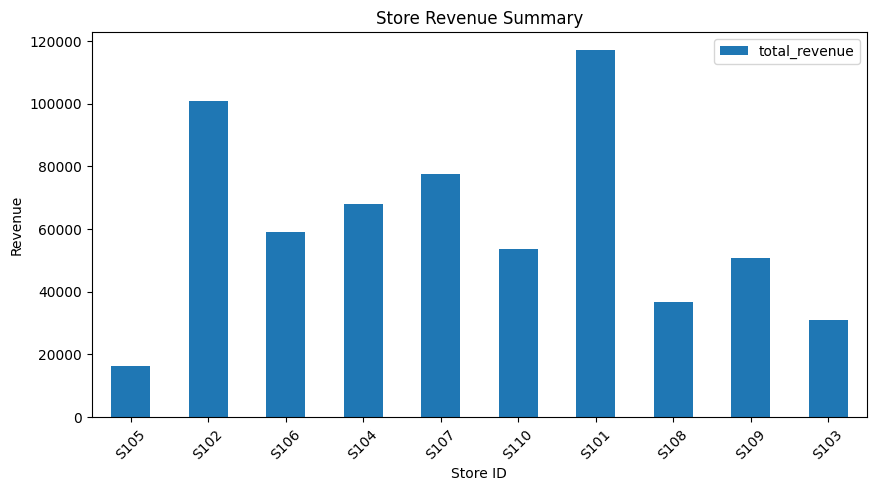

In [34]:
# VISUALIZATIOn

import matplotlib.pyplot as plt

store_pd = store_summary.toPandas()

store_pd.plot(
    x="store_id",
    y="total_revenue",
    kind="bar",
    figsize=(10,5)
)

plt.title("Store Revenue Summary")
plt.xlabel("Store ID")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()